# Warnings and Library Loading


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

# Data loading

In [5]:
df=pd.read_csv('data/youtube_ad_revenue_dataset.csv')
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


# Dataset Shape Analysis

The shape of a dataset provides information about the number of rows (observations) and columns (features) present in the dataset.

In this step, we check the dimensions of the dataset to understand its overall size before performing further analysis.

Rows represent individual records, while columns represent the features available for analysis and model building.

In [6]:
df.shape

(122400, 12)

### Observation

The dataset contains 122,400 rows and 12 columns.

This indicates that the dataset is sufficiently large for performing machine learning tasks and building a robust regression model.

The dataset consists of one target variable (ad_revenue_usd) and multiple independent variables that may influence revenue generation.

# Dataset Information :: df.info()

This step provides a detailed overview of the dataset structure, including column names, data types, non-null values, and memory usage.

Understanding the dataset schema is important before performing data cleaning, feature engineering, and model building.

It also helps identify categorical and numerical features, as well as potential missing values that may require preprocessing.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  str    
 1   date                  122400 non-null  str    
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  str    
 9   device                122400 non-null  str    
 10  country               122400 non-null  str    
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), str(5)
memory usage: 16.9 MB


### Observation

The dataset contains a mix of numerical and categorical features.

Most columns appear to be complete, while some columns may contain missing values that need to be handled during preprocessing.

The dataset structure is suitable for regression analysis and predictive modeling.

# Statistical Summary : Use of describe function.

This step provides descriptive statistics for all numerical features in the dataset.

The summary includes measures such as count, mean, standard deviation, minimum, maximum, and quartile values.

These statistics help in understanding the distribution of data and identifying potential outliers before further analysis.

In [8]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


### Observation:

This dataset appears relatively well-controlled and balanced.
No strong evidence of extreme outliers is visible from the statistical summary alone.
Further validation using boxplots and IQR analysis is required.

# Missing Value Analysis

Missing values can affect data quality and model performance if not handled properly.

In this step, we identify columns containing missing values and measure the extent of missing data present in the dataset.

Understanding missing values helps in selecting an appropriate imputation strategy during preprocessing.

In [9]:
round(df.isnull().sum()/len(df)*100,2)

video_id                0.00
date                    0.00
views                   0.00
likes                   5.00
comments                4.99
watch_time_minutes      4.99
video_length_minutes    0.00
subscribers             0.00
category                0.00
device                  0.00
country                 0.00
ad_revenue_usd          0.00
dtype: float64

### Observation

The dataset contains missing values in the likes, comments, and watch_time_minutes columns, with approximately 5% missing data in each feature.

The amount of missing data is relatively low and can be handled during preprocessing using appropriate imputation techniques.

No missing values are present in the target variable (ad_revenue_usd).

# Duplicate Record Analysis

Duplicate records can introduce bias into the analysis and negatively affect model performance.

This step identifies duplicate rows present in the dataset before further preprocessing.

In [10]:
df.duplicated().sum()

np.int64(2400)

### Observation

A total of 2,400 duplicate records were identified in the dataset.

These duplicate entries may introduce bias into the analysis and model training process.

Therefore, duplicate records will be removed during the data preprocessing stage to improve data quality and ensure reliable model performance.

# Feature Classification

Before performing exploratory data analysis, it is important to classify features into numerical and categorical variables.

This helps in selecting appropriate visualization techniques and preprocessing methods for each feature type during analysis and model development.

In [11]:
num_cols=df.select_dtypes(include="number").columns
num_cols



Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'ad_revenue_usd'],
      dtype='str')

In [12]:
cat_cols=df.select_dtypes(include="object").columns
cat_cols

Index(['video_id', 'date', 'category', 'device', 'country'], dtype='str')

# Target Variable Analysis

The target variable for this project is ad_revenue_usd, which represents the revenue generated from a video.

Understanding the distribution of the target variable is important before model building, as it helps identify patterns, skewness, and potential outliers.

This analysis provides a better understanding of the prediction problem and the overall behavior of revenue values in the dataset.

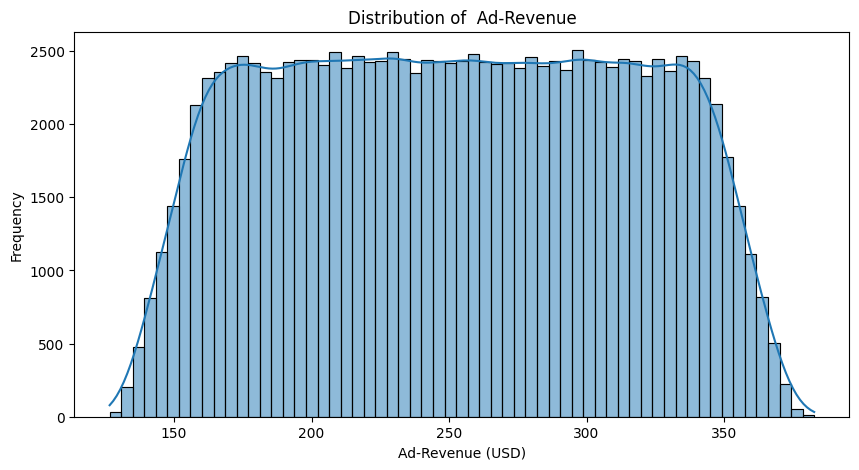

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['ad_revenue_usd'], kde=True)

plt.title("Distribution of  Ad-Revenue")

plt.xlabel("Ad-Revenue (USD)")
plt.ylabel("Frequency")

plt.show()

### Observation

The target variable (ad_revenue_usd) appears to be fairly evenly distributed across its range.

No significant skewness or extreme peaks are visible in the distribution.

The revenue values are spread between approximately 125 USD and 380 USD, indicating a balanced target variable with no obvious outlier concentration.

This distribution is favorable for regression modeling, as the target variable does not appear to be heavily imbalanced.

# Univariate Analysis - Views

Views represent the total number of times a video has been watched.

Since advertising revenue is closely related to audience reach, analyzing the distribution of views helps understand user engagement and its potential impact on revenue generation.

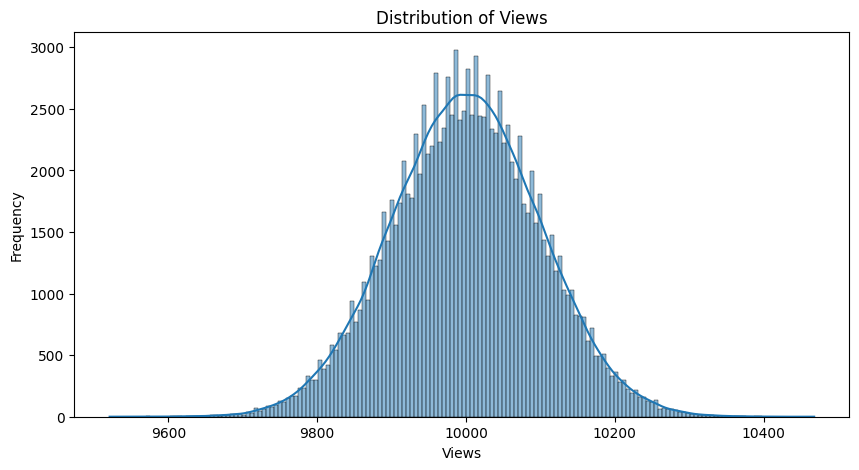

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(df['views'], kde=True)

plt.title("Distribution of Views")

plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()

### Boxplot Method to analyse VIEWS

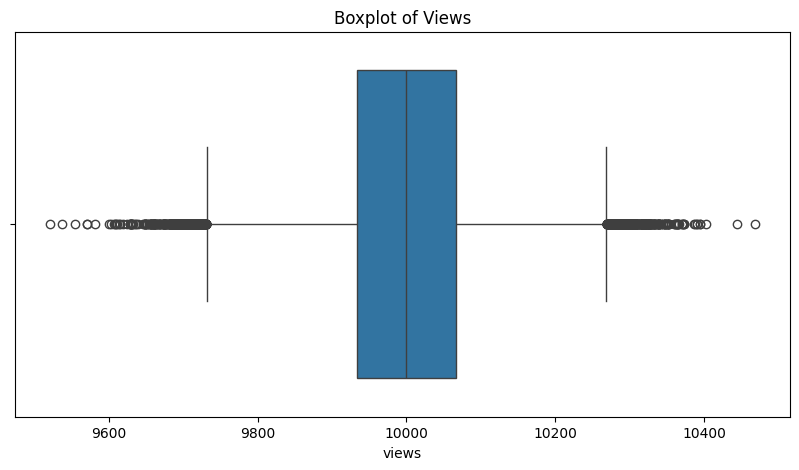

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['views'])

plt.title("Boxplot of Views")

plt.show()

### Observation

The distribution of views appears approximately normal, with most videos receiving around 10,000 views.

The histogram shows a symmetric bell-shaped pattern, indicating that the feature is fairly balanced and does not exhibit strong skewness.

The boxplot reveals the presence of some outliers on both the lower and upper ends. However, these outliers are limited in number and are expected in large datasets.

Overall, the views feature appears well distributed and suitable for further analysis and model building.

# Univariate Analysis - Likes

Likes represent the number of positive interactions received by a video.

Analyzing the distribution of likes helps understand audience engagement and provides insights into user response patterns.

Since engagement metrics often influence content monetization, examining likes is important for understanding potential revenue drivers.

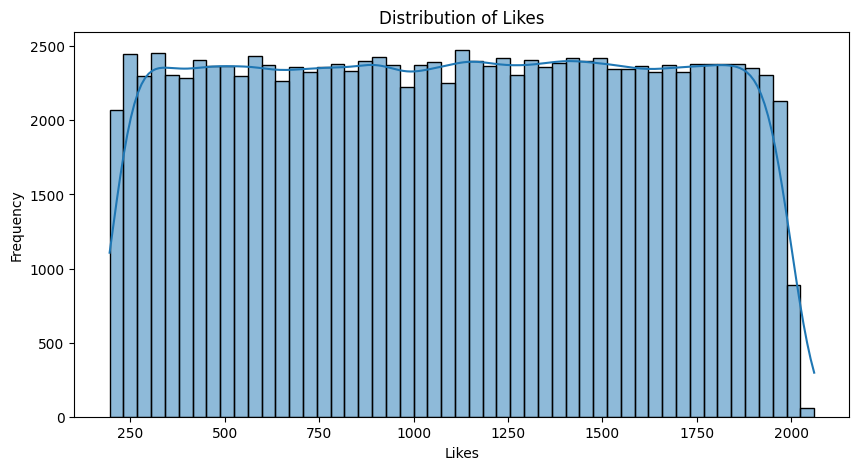

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df['likes'], kde=True)

plt.title("Distribution of Likes")

plt.xlabel("Likes")
plt.ylabel("Frequency")

plt.show()

### Boxplot - likes

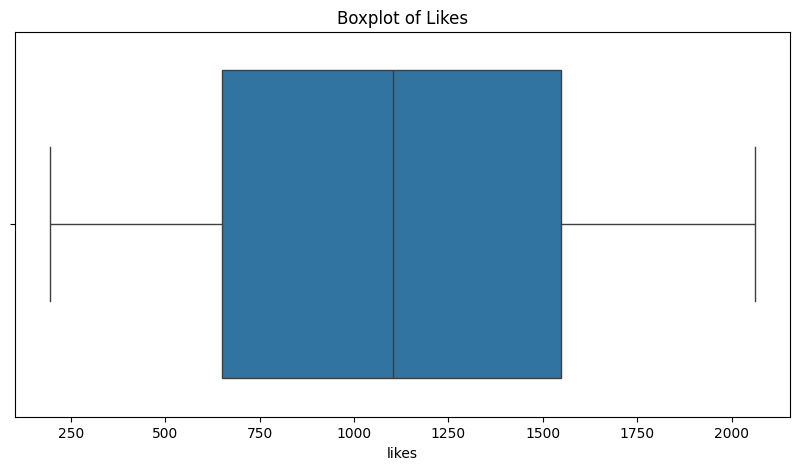

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['likes'])

plt.title("Boxplot of Likes")

plt.show()

### Observation

The likes feature appears to be fairly evenly distributed across its range, with values spread between approximately 200 and 2,100 likes.

The histogram does not show strong skewness or concentration around a particular value, indicating a balanced distribution.

The boxplot does not reveal any significant outliers, suggesting that the likes feature is well-behaved and consistent across observations.

Overall, the likes feature appears suitable for statistical analysis and machine learning model development.

# Univariate Analysis - Comments

Comments represent audience interaction and engagement with a video.

Analyzing the distribution of comments helps understand user participation levels and audience response patterns.

Since engagement metrics can influence content performance and monetization, comments are an important feature for analysis.

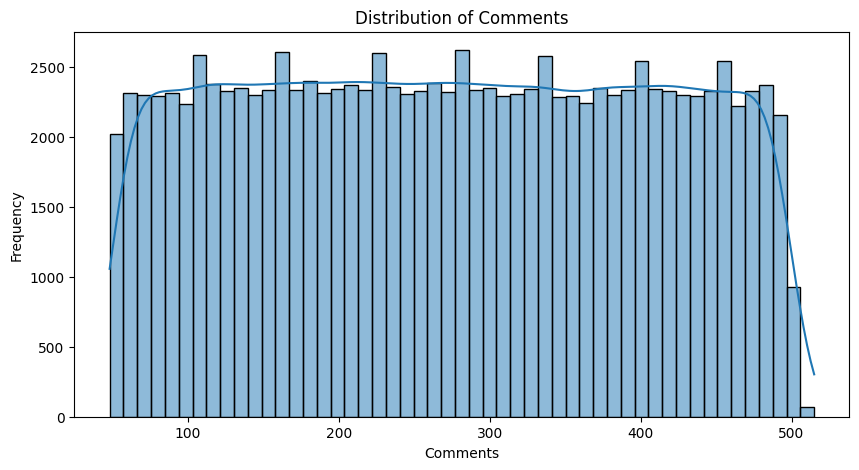

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df['comments'], kde=True)

plt.title("Distribution of Comments")

plt.xlabel("Comments")
plt.ylabel("Frequency")

plt.show()

### Boxplot- Comments 

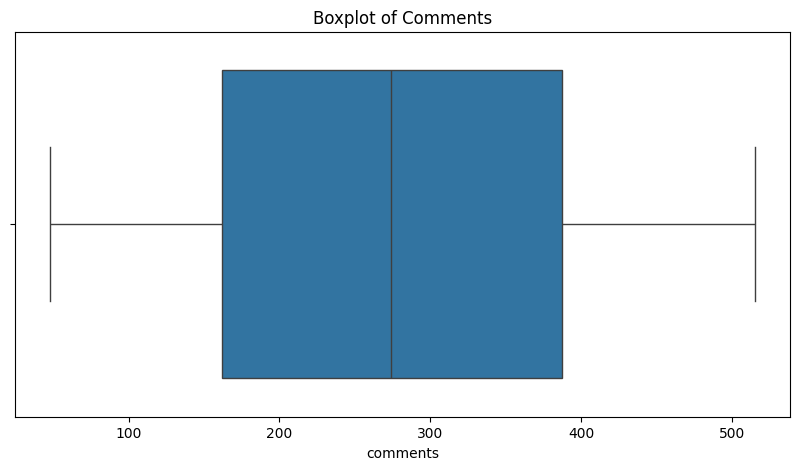

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['comments'])

plt.title("Boxplot of Comments")

plt.show()

### Observation

The comments feature appears to be evenly distributed across its range, with values spread between approximately 50 and 520 comments.

The histogram does not show significant skewness, indicating a balanced distribution of audience interactions.

The boxplot does not reveal any major outliers, suggesting that comment counts are relatively consistent across videos.

Overall, the comments feature is well distributed and suitable for further analysis and predictive modeling.

# Univariate Analysis - Watch Time Minutes

Watch time represents the total amount of time viewers spend watching a video.

It is one of the most important engagement metrics, as higher watch time often indicates stronger audience retention and content quality.

Analyzing the distribution of watch time helps understand viewer behavior and its potential impact on ad revenue generation.

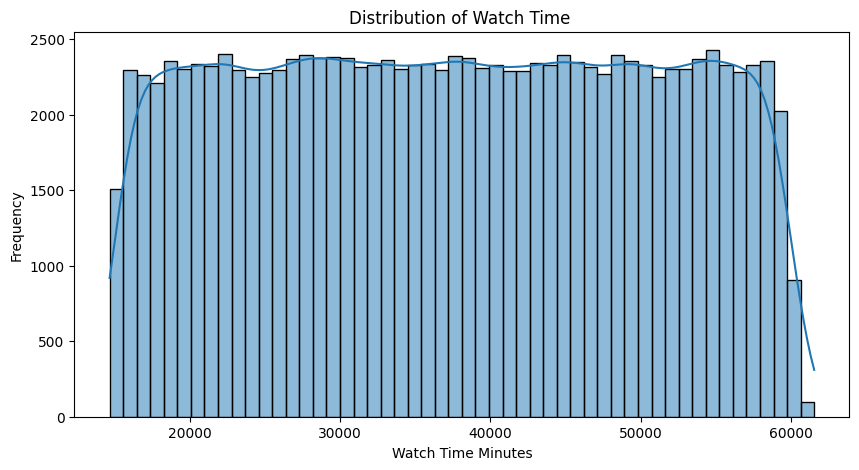

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['watch_time_minutes'], kde=True)

plt.title("Distribution of Watch Time ")
plt.xlabel("Watch Time Minutes")
plt.ylabel("Frequency")

plt.show()

### Boxplot - Watch time Minutes

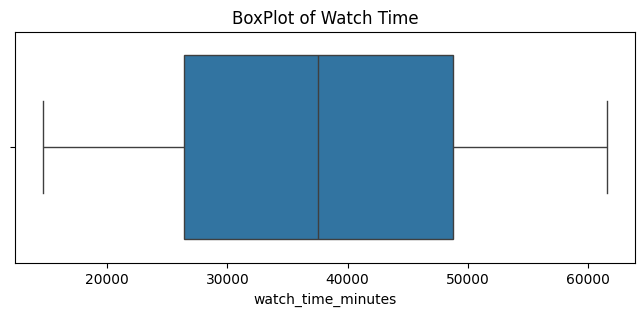

In [21]:
plt.figure(figsize=(8,3))

sns.boxplot(x=df['watch_time_minutes'])

plt.title("BoxPlot of Watch Time")

plt.show()

### Observation

The watch_time_minutes feature appears to be evenly distributed across its range, with values spanning approximately from 15,000 to 62,000 minutes.

The histogram does not exhibit significant skewness and shows a balanced distribution of watch time values.

The boxplot does not indicate the presence of major outliers, suggesting that watch time is relatively consistent across videos.

Overall, the feature is well distributed and can be considered a stable predictor for revenue analysis and machine learning modeling.

# Univariate Analysis - Video Length Minutes

Video length represents the duration of a video in minutes.

Analyzing video length helps understand content characteristics and provides insights into whether shorter or longer videos are more common in the dataset.

This feature may also influence audience retention, watch time, and ultimately revenue generation.

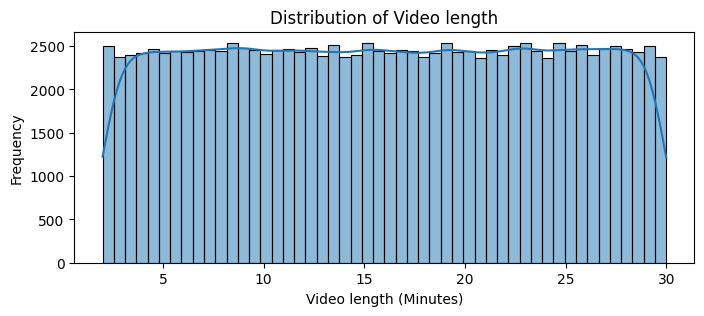

In [22]:
plt.figure(figsize=(8,3))

sns.histplot(df['video_length_minutes'], kde=True)

plt.title("Distribution of Video length")

plt.xlabel("Video length (Minutes)")
plt.ylabel("Frequency")

plt.show()

### Boxplot- Video Length In Minutes

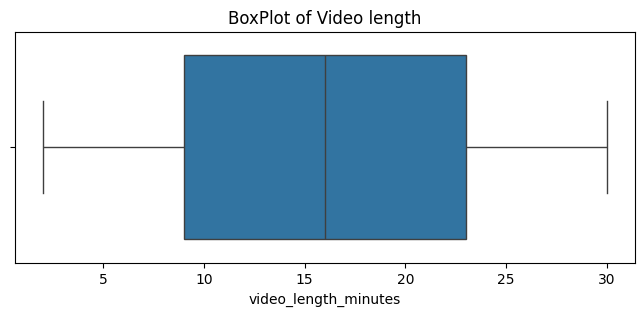

In [23]:
plt.figure(figsize=(8,3))

sns.boxplot(x=df['video_length_minutes'])

plt.title("BoxPlot of Video length")

plt.show()

### Observation

The video_length_minutes feature is evenly distributed across its range, with video durations varying from approximately 2 to 30 minutes.

The histogram indicates a balanced distribution without noticeable skewness or concentration around a specific duration.

The boxplot does not reveal any significant outliers, suggesting that video lengths are consistently distributed throughout the dataset.

Overall, the feature appears clean and suitable for further analysis and predictive modeling.

# Univariate Analysis - Subscribers

Subscribers represent the size of a creator's audience and indicate the potential reach of future content.

Analyzing the distribution of subscribers helps understand the variation in channel popularity across the dataset.

Since audience size can influence views, engagement, and monetization, subscribers are an important feature for revenue prediction.

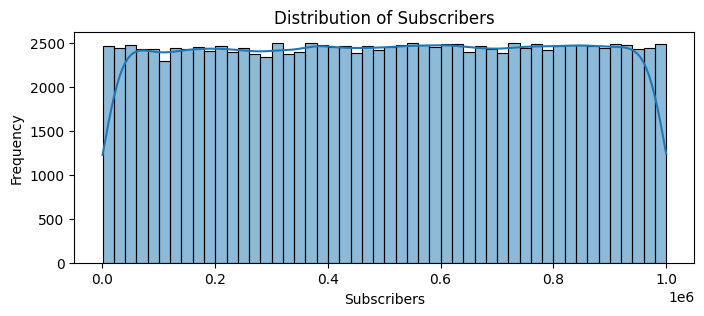

In [24]:
plt.figure(figsize=(8,3))

sns.histplot(df['subscribers'], kde=True)

plt.title("Distribution of Subscribers")
plt.xlabel("Subscribers")
plt.ylabel("Frequency")

plt.show()

### Boxplot- Subscribers

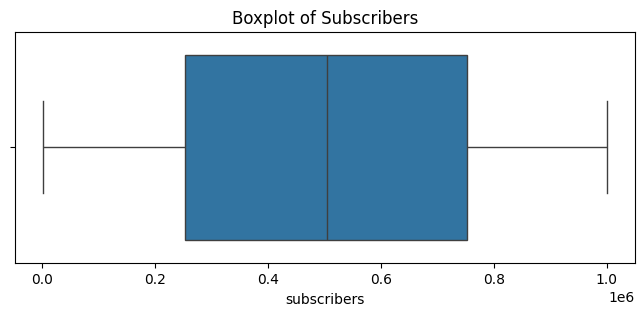

In [25]:
plt.figure(figsize=(8,3))

sns.boxplot(x=df['subscribers'])

plt.title("Boxplot of Subscribers")

plt.show()

### Observation

The subscribers feature is evenly distributed across its range, with channel sizes varying from approximately 1,000 to 1,000,000 subscribers.

The histogram shows a balanced distribution without significant skewness or concentration in any particular range.

The boxplot does not indicate the presence of major outliers, suggesting that subscriber counts are consistently distributed throughout the dataset.

Overall, the subscribers feature appears clean and suitable for further statistical analysis and machine learning modeling.

# Categorical Analysis - Category

The category feature represents the type of content published on the platform.

Analyzing category distribution helps understand the composition of the dataset and identify which content categories are most frequently represented.

This analysis provides useful context before examining the relationship between content categories and ad revenue.

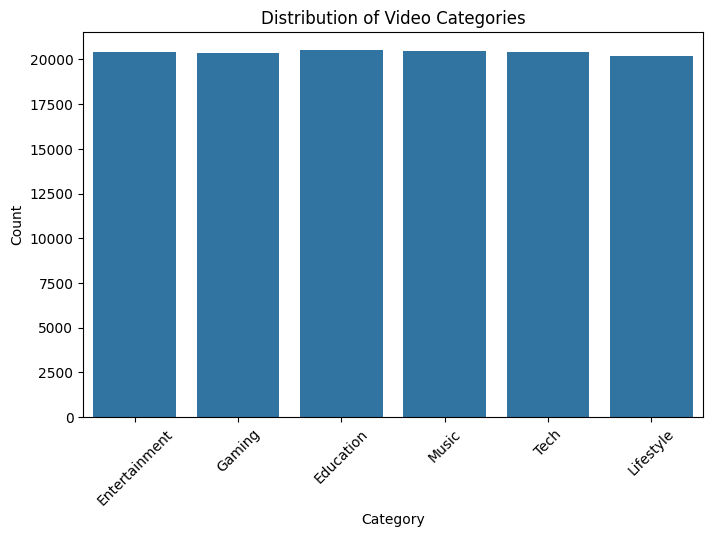

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='category')
plt.title("Distribution of Video Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

The dataset contains a balanced representation of all content categories, including Entertainment, Gaming, Education, Music, Tech, and Lifestyle.

No single category dominates the dataset, indicating that content is evenly distributed across different categories.

This balanced distribution is beneficial for comparative analysis and helps prevent category-specific bias during model training.

# Categorical Analysis - Device

The device feature represents the type of device used by viewers to consume video content.

Analyzing device distribution helps understand audience viewing preferences across different platforms.

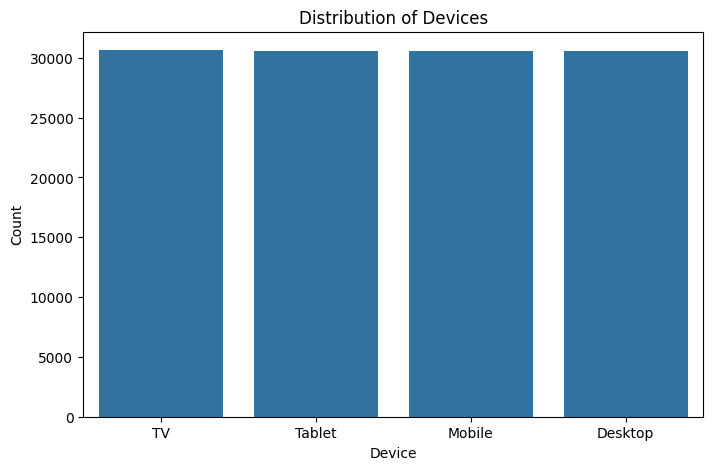

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='device')

plt.title("Distribution of Devices")
plt.xlabel("Device")
plt.ylabel("Count")

plt.show()

### Observation

The distribution of devices is nearly uniform across TV, Tablet, Mobile, and Desktop platforms.

No device category appears significantly overrepresented, suggesting a balanced audience distribution across viewing platforms.

This balance supports unbiased analysis of device-related viewing behavior and monetization patterns.

# Categorical Analysis - Country

The country feature represents the geographical location of viewers.

Analyzing country distribution helps identify the regional composition of the dataset and provides insights into audience diversity.

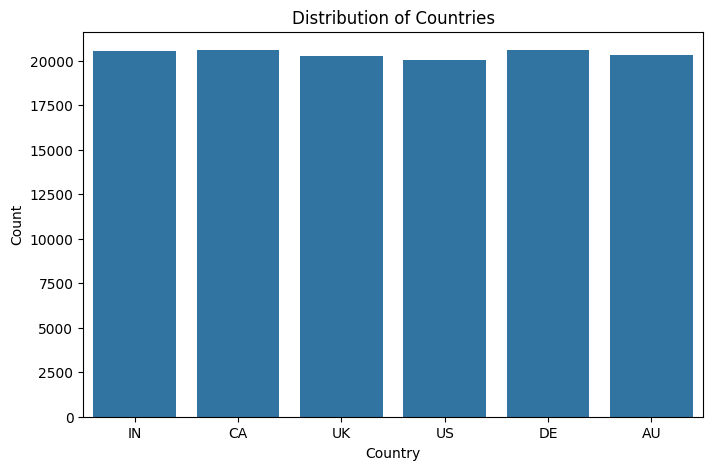

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='country')

plt.title("Distribution of Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

### Observation

The dataset contains a balanced representation of viewers from multiple countries, including India, Canada, the United Kingdom, the United States, Germany, and Australia.

No country appears to dominate the dataset, indicating a diverse and well-distributed international audience.

This balanced geographical representation is useful for comparative regional analysis and machine learning model development.

# Bivariate Analysis - Revenue vs Views

Views represent the audience reach of a video, while ad_revenue_usd represents the revenue generated.

Analyzing the relationship between views and revenue helps determine whether higher audience reach contributes to increased monetization.

This analysis provides valuable business insights into the impact of viewership on revenue generation.

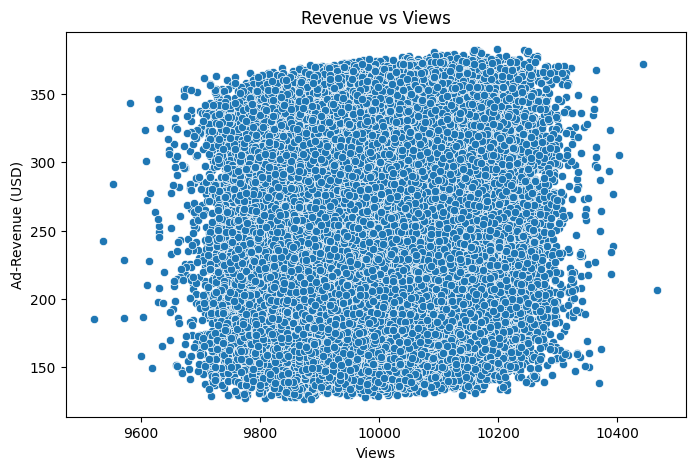

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='views',
    y='ad_revenue_usd'
)

plt.title("Revenue vs Views")

plt.xlabel("Views")
plt.ylabel("Ad-Revenue (USD)")

plt.show()

### Observation

The relationship between views and ad revenue appears to be weak.

Although videos receive a similar range of views, revenue values vary significantly across observations.

The scatter plot does not show a strong upward trend, indicating that views alone may not be a strong predictor of ad revenue in this dataset.

### Revenue vs Likes

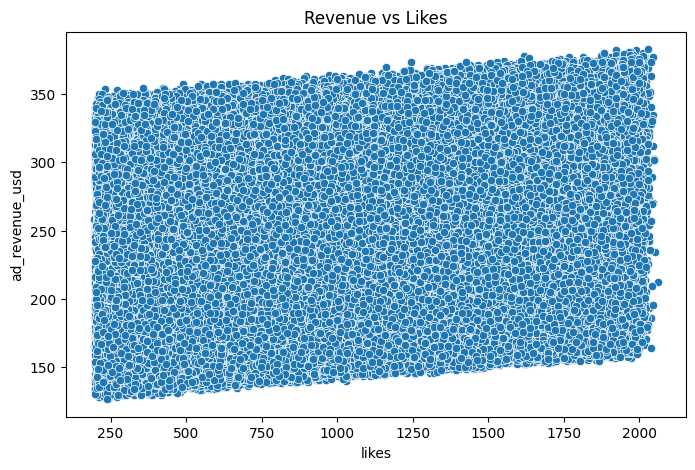

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="likes",
    y="ad_revenue_usd"
)

plt.title("Revenue vs Likes")

plt.show()

### Observation

The relationship between likes and ad revenue appears to be positive but relatively weak.

As the number of likes increases, revenue tends to increase slightly; however, substantial variation still exists.

This suggests that likes may contribute to revenue generation but are not the primary driver of monetization.

### Revenue vs Comments

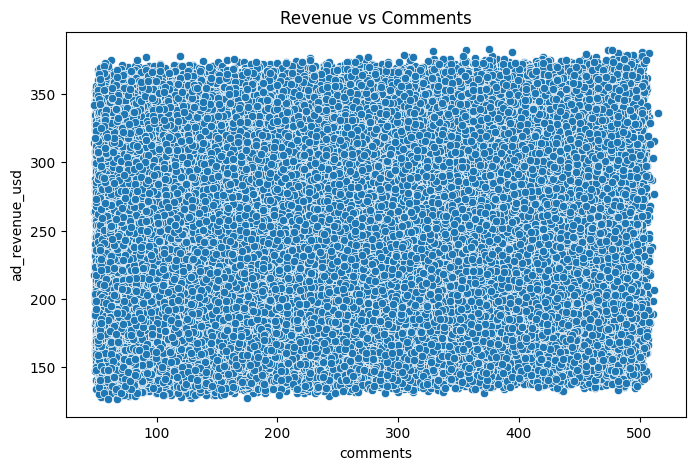

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="comments",
    y="ad_revenue_usd"
)
plt.title("Revenue vs Comments")
plt.show()

### Observation

The relationship between comments and ad revenue appears weak.

Revenue values remain widely distributed across all comment levels, with no clear upward trend visible in the scatter plot.

This suggests that comments alone may have limited predictive power for ad revenue.

### Revenue vs Watch Time

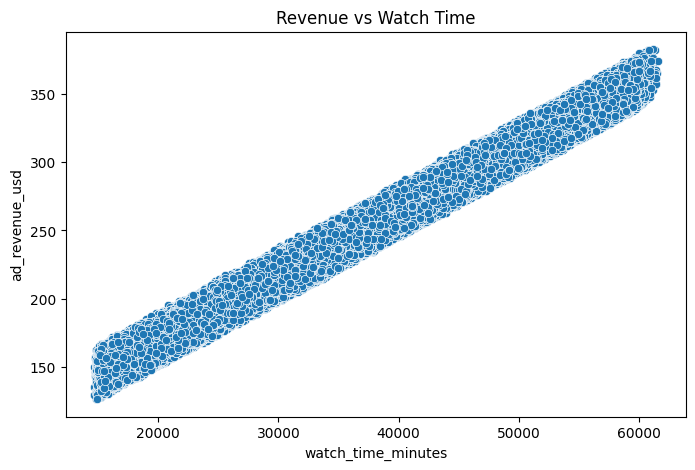

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="watch_time_minutes",
    y="ad_revenue_usd"
)

plt.title("Revenue vs Watch Time")

plt.show()

### Observation

A very strong positive relationship exists between watch_time_minutes and ad_revenue_usd.

The scatter plot shows a clear upward trend, indicating that higher watch time is consistently associated with higher revenue.

Among all analyzed features, watch time appears to be the strongest predictor of ad revenue.

### Revenue vs Subscribers

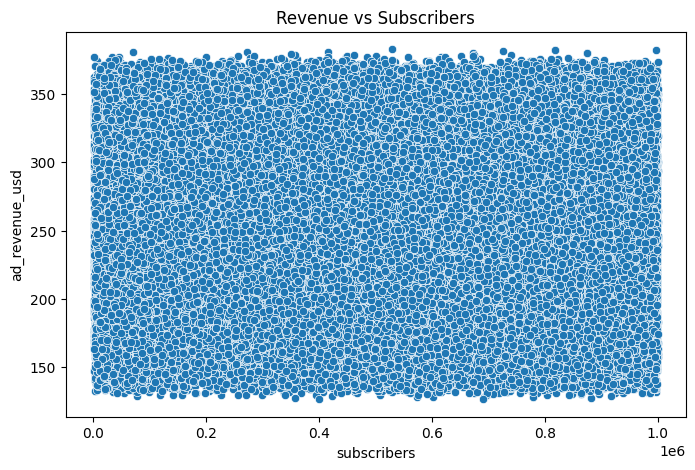

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="subscribers",
    y="ad_revenue_usd"
)

plt.title("Revenue vs Subscribers")

plt.show()

### Observation

The relationship between subscribers and ad revenue appears very weak.

Revenue values are spread across the entire subscriber range without a clear pattern or trend.

This indicates that subscriber count alone may not be a reliable predictor of ad revenue in this dataset.

# Correlation Analysis

Correlation analysis helps measure the strength and direction of relationships between numerical variables.

It is useful for identifying the features that are most strongly associated with ad revenue and understanding interactions among predictors.

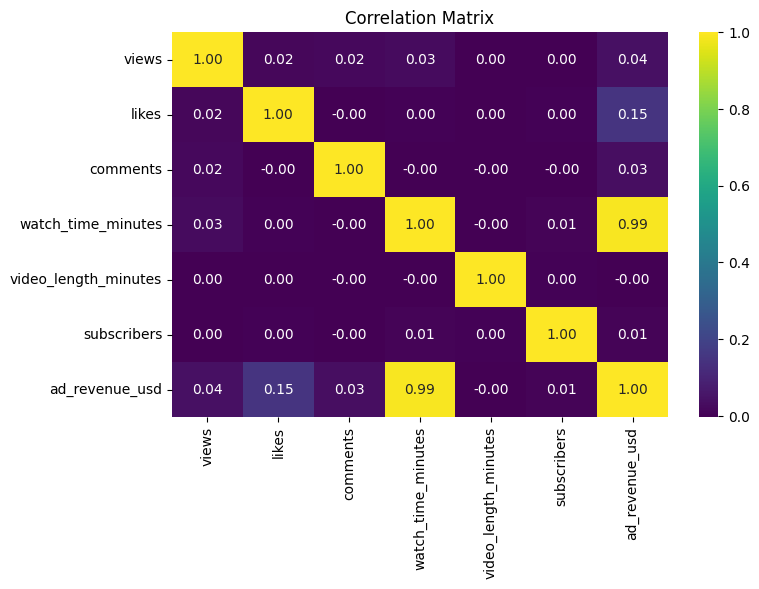

In [34]:
plt.figure(figsize=(8,5))

corr=df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Analysis Observation

Correlation analysis reveals that watch_time_minutes has the strongest relationship with ad_revenue_usd, with a correlation coefficient of 0.99.

Likes show a weak positive relationship with revenue (0.15), while views (0.04), comments (0.03), and subscribers (0.01) have almost no correlation with revenue.

Video length also shows virtually no direct relationship with ad revenue.

These results indicate that watch time is the most important predictor of ad revenue in this dataset.

### Data Preprocessing 

#### Date Column Analysis

The dataset contains a date column which may hold valuable temporal information.

Before model building, it is important to inspect and understand the date feature, determine its data type, and evaluate whether additional features can be extracted from it.

This step helps identify potential time-based patterns that may influence ad revenue.

In [35]:
df['date'].head()

0    2024-09-24 10:50:40.993199
1    2024-09-22 10:50:40.993199
2    2024-11-21 10:50:40.993199
3    2025-01-28 10:50:40.993199
4    2025-04-28 10:50:40.993199
Name: date, dtype: str

In [36]:
df['date'].nunique()

365

# Date Datatype Conversion

The date column is currently stored as a string.

To perform date-based feature engineering, it must first be converted into datetime format.

This enables extraction of useful temporal features such as year, month, day, and weekday.

The date column contains 365 unique values, indicating that the dataset spans approximately one year of observations.

Multiple records exist for each date, suggesting that several videos were recorded or tracked on the same day.

This makes the date feature a strong candidate for feature engineering.

In [37]:
df['date']=pd.to_datetime(df['date'])

In [38]:
df['date'].dtype

dtype('<M8[us]')

In [39]:
df['date'].min()

Timestamp('2024-06-09 10:50:40.993199')

In [40]:
df['date'].max()

Timestamp('2025-06-08 10:50:40.993199')

In [41]:
df['date'].head()

0   2024-09-24 10:50:40.993199
1   2024-09-22 10:50:40.993199
2   2024-11-21 10:50:40.993199
3   2025-01-28 10:50:40.993199
4   2025-04-28 10:50:40.993199
Name: date, dtype: datetime64[us]

In [42]:
df['date'].tail()

122395   2024-12-14 10:50:40.993199
122396   2024-07-13 10:50:40.993199
122397   2024-06-10 10:50:40.993199
122398   2024-12-22 10:50:40.993199
122399   2024-06-25 10:50:40.993199
Name: date, dtype: datetime64[us]

In [43]:
df['date'].describe()

count                        122400
mean     2024-12-08 04:34:02.169670
min      2024-06-09 10:50:40.993199
25%      2024-09-07 10:50:40.993199
50%      2024-12-08 10:50:40.993199
75%      2025-03-09 10:50:40.993199
max      2025-06-08 10:50:40.993199
Name: date, dtype: object

### Observation

The date column has been successfully converted from string to datetime format.

The dataset spans from June 2024 to June 2025, covering approximately one year of observations.

A total of 365 unique dates are present, indicating daily records across the year.

Since the date column contains temporal information, it can be used to generate additional features such as year, month, day, and day of week for machine learning.

# Date Feature Engineering

The date column contains useful temporal information that may influence ad revenue.

To help machine learning models identify time-based patterns, additional features such as year, month, day, and weekday will be extracted from the date column.

These derived features may improve model performance by capturing seasonal and temporal trends.

In [44]:
df['year']=df['date'].dt.year

In [45]:
df['month']=df['date'].dt.month

In [46]:
df['day']=df['date'].dt.day

In [47]:
df['day_of_week']=df['date'].dt.day_name()

### Checking for head agian

In [48]:
df[['date','year','month','day','day_of_week']].head()


,date,year,month,day,day_of_week
0,2024-09-24 10:50:40.993199,2024,9,24,Tuesday
1,2024-09-22 10:50:40.993199,2024,9,22,Sunday
2,2024-11-21 10:50:40.993199,2024,11,21,Thursday
3,2025-01-28 10:50:40.993199,2025,1,28,Tuesday
4,2025-04-28 10:50:40.993199,2025,4,28,Monday


### Observation

The date column has been successfully transformed into multiple time-based features.

New features such as year, month, day, and day_of_week have been extracted from the original date column.

These features may help the model capture temporal patterns, seasonal trends, and weekday effects that could influence ad revenue.

The dataset is now more informative and machine-learning friendly compared to using the raw date column.

### Purpose of Date Feature Analysis

After extracting year, month, and day_of_week from the date column, we have to analyze their distributions.

The objective is to verify whether these features contain sufficient variation across the dataset.

Features with meaningful variation can help the model learn seasonal trends, monthly patterns, or weekday effects related to ad revenue.

This analysis helps us decide whether these engineered features should be retained during model building.

### Year Distribution:

In [49]:
df['year'].value_counts()

year
2024    69102
2025    53298
Name: count, dtype: int64

### Year Analysis Observation

The dataset contains records from both 2024 and 2025.

2024 has slightly more observations than 2025, but both years are reasonably represented.

Since the dataset spans multiple years, the year feature may capture long-term trends and will be retained for further analysis.

### Month Distribution

In [50]:
df['month'].value_counts()

month
3     10524
8     10513
10    10510
1     10472
5     10361
7     10291
12    10289
11    10063
6     10032
4     10008
9      9994
2      9343
Name: count, dtype: int64

### Month Analysis Observation

The distribution across months is fairly balanced.

All months contain a similar number of records, indicating no major imbalance.

This suggests that month-based seasonal effects can be studied and the month feature should be retained.

### Day of Week Distribution

In [51]:
df['day_of_week'].value_counts()

day_of_week
Sunday       17651
Tuesday      17577
Monday       17531
Wednesday    17513
Thursday     17510
Saturday     17315
Friday       17303
Name: count, dtype: int64

### Day of Week Analysis Observation

All weekdays are almost equally represented in the dataset.

No single weekday dominates the data.

The day_of_week feature may help capture user engagement differences between weekdays and weekends and will be retained.

### Missing value Check:

In [52]:
round(df.isnull().sum()/len(df)*100,2)

video_id                0.00
date                    0.00
views                   0.00
likes                   5.00
comments                4.99
watch_time_minutes      4.99
video_length_minutes    0.00
subscribers             0.00
category                0.00
device                  0.00
country                 0.00
ad_revenue_usd          0.00
year                    0.00
month                   0.00
day                     0.00
day_of_week             0.00
dtype: float64

### Missing Value Treatment

In [53]:
df[['likes','comments','watch_time_minutes']].describe()

,likes,comments,watch_time_minutes
count,116283.000000,116288.000000,116295.000000
mean,1099.633618,274.396636,37543.827721
std,519.424089,129.741739,12987.724246
min,195.000000,48.000000,14659.105562
25%,650.000000,162.000000,26366.320569
50%,1103.000000,274.000000,37531.990337
75%,1547.000000,387.000000,48777.782090
max,2061.000000,515.000000,61557.670089


### Missing Value Analysis Observation

The columns likes, comments, and watch_time_minutes contain approximately 5% missing values.

The mean and median values of all three columns are very close to each other, indicating that the distributions are fairly balanced and not heavily skewed.

Although likes showed some outliers during boxplot analysis, the overall distribution remains stable because the dataset contains more than 122,000 records.

Therefore, the impact of a small number of outliers on the mean is minimal.

### Filling of Missing Values carefully:

In [54]:
df['likes']=df['likes'].fillna(df['likes'].mean(), inplace=True)

In [55]:
df['comments']=df['comments'].fillna(df['comments'].mean(), inplace=True)

In [56]:
df['watch_time_minutes']=df['watch_time_minutes'].fillna(df['watch_time_minutes'].mean(), inplace=True)

In [57]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
year                    0
month                   0
day                     0
day_of_week             0
dtype: int64

### Missing Value Treatment Observation

Missing values were identified in likes, comments, and watch_time_minutes.

Mean imputation was selected because the distributions were relatively balanced and the mean and median values were very close.

After applying imputation, all missing values were successfully replaced, resulting in a complete dataset with no null values.

## Duplicate Detection

Duplicate records were checked to identify repeated observations in the dataset.

Duplicate observations can introduce bias into machine learning models because the same information may be learned multiple times.

Therefore, the dataset was examined for duplicate records before proceeding with further preprocessing and model development.


In [58]:
df.duplicated().sum()

np.int64(2400)

## Duplicate Detection Observation

A duplicate check was performed on the dataset to identify repeated records.

The analysis revealed a total of 2400 duplicate observations.

Duplicate records can negatively impact machine learning models by introducing redundant information and increasing the likelihood of biased learning.

Therefore, duplicate records will be removed before proceeding with feature engineering, model training, and evaluation.


## Duplicate Treatment

In [59]:
df = df.drop_duplicates()

In [60]:
df.shape

(120000, 16)

In [61]:
df.duplicated().sum()

np.int64(0)

## Duplicate Treatment Observation

A total of 2400 duplicate records were identified in the dataset.

To ensure data quality and prevent redundant information from influencing the machine learning models, all duplicate observations were removed using the `drop_duplicates()` function.

After treatment, the dataset size was reduced from 122,400 records to 120,000 unique records.

A final verification confirmed that no duplicate records remained in the dataset, making it suitable for further preprocessing, feature engineering, and model development.


### Dropping Unique Identifier

The video_id column is a unique identifier for each record.

It does not contain any meaningful information that can help predict ad revenue.

Therefore, it will be removed before model training.

In [62]:
df.drop('video_id', axis=1, inplace=True, errors='ignore')

In [63]:
df.columns

Index(['date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'year', 'month', 'day', 'day_of_week'],
      dtype='str')

### Removing Original Date Column

The original date column has already been decomposed into year, month, day, and day_of_week features.

Keeping both the raw date and the extracted components would introduce redundant information.

Therefore, the original date column is removed before model training.

In [64]:
df.drop('date', axis=1, inplace=True, errors='ignore')

In [65]:
df.columns

Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'year', 'month', 'day', 'day_of_week'],
      dtype='str')

### Categorical Feature Cardinality Check

Before applying encoding, it is important to identify the number of unique values present in each categorical feature.

This analysis helps us understand the complexity of each categorical column and determine the most suitable encoding technique.

Features with a small number of unique categories are generally good candidates for One-Hot Encoding, while high-cardinality features may require alternative approaches.

Understanding category counts also helps estimate the number of new features that will be created after encoding.

In [66]:
print(df.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'year', 'month', 'day', 'day_of_week'],
      dtype='str')>


In [67]:
df[['category','device','country','day_of_week']].nunique()

category       6
device         4
country        6
day_of_week    7
dtype: int64

### Categorical Cardinality Observation

All categorical features contain a relatively small number of unique categories.

Category contains 6 unique values, Device contains 4 unique values, Country contains 6 unique values, and Day_of_Week contains 7 unique values.

Since all categorical columns have low cardinality, they are suitable candidates for One-Hot Encoding.

This will allow machine learning models to interpret categorical information without introducing artificial numerical relationships.

### Categorical Encoding

Machine learning algorithms require numerical inputs and cannot directly process text-based categorical values.

Since all categorical features have low cardinality, One-Hot Encoding will be applied.

This technique converts each category into separate binary columns while preserving the absence of any natural ranking between categories.

In [68]:
cat_cols=['category','device','country','day_of_week']
df[cat_cols].head()

,category,device,country,day_of_week
0,Entertainment,TV,IN,Tuesday
1,Gaming,Tablet,CA,Sunday
2,Education,TV,CA,Thursday
3,Entertainment,Mobile,UK,Tuesday
4,Education,Mobile,CA,Monday


### Categorical Features Verification

The categorical columns were inspected before encoding.

The dataset contains text-based categories representing content type, viewing device, country, and day of the week.

Since machine learning models cannot directly process string values, these features must be converted into numerical representations before model training.

### Applying One-Hot Encoding

The categorical variables contain nominal categories with no natural ordering.

To convert these text values into machine-readable numerical features, One-Hot Encoding will be applied.

This creates separate binary columns for each category while preventing the introduction of artificial ranking relationships.

In [69]:
print(df.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'year', 'month', 'day', 'day_of_week'],
      dtype='str')>


In [70]:
df=pd.get_dummies(
    df,
    columns=['category','device','country','day_of_week'],
    drop_first= True
)

In [71]:
df.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,year,month,day,category_Entertainment,category_Gaming,category_Lifestyle,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,2024,9,24,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False
1,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,2024,9,22,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False
2,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,2024,11,21,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
3,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,2025,1,28,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False
4,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,2025,4,28,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False


In [72]:
df.shape

(120000, 29)

### One-Hot Encoding Observation

All categorical variables were successfully transformed into numerical features using One-Hot Encoding.

The original categorical columns were replaced by binary indicator columns containing True/False values.

The dataset shape increased from 14 features to 29 features because each category was converted into separate machine-readable columns.

The dataset is now fully numerical and ready for machine learning model development.

### Encoding Validation Observation

One-Hot Encoding was successfully applied to all categorical variables.

The newly created columns are stored as boolean (True/False) values, which are acceptable for machine learning algorithms.

Since drop_first=True was used, one category from each feature was automatically removed to avoid multicollinearity (Dummy Variable Trap).

No additional categorical columns remain in the dataset.

In [73]:
df.dtypes

views                       int64
likes                     float64
comments                  float64
watch_time_minutes        float64
video_length_minutes      float64
subscribers                 int64
ad_revenue_usd            float64
year                        int32
month                       int32
day                         int32
category_Entertainment       bool
category_Gaming              bool
category_Lifestyle           bool
category_Music               bool
category_Tech                bool
device_Mobile                bool
device_TV                    bool
device_Tablet                bool
country_CA                   bool
country_DE                   bool
country_IN                   bool
country_UK                   bool
country_US                   bool
day_of_week_Monday           bool
day_of_week_Saturday         bool
day_of_week_Sunday           bool
day_of_week_Thursday         bool
day_of_week_Tuesday          bool
day_of_week_Wednesday        bool
dtype: object

## Feature and Target Separation

Before training a machine learning model, the dataset must be divided into Features (X) and Target Variable (y).

Features are the input variables that help the model learn patterns from the data.

The target variable is the output that the model is expected to predict.

In this project, Ad Revenue is selected as the target variable because the objective is to predict the revenue generated by a video based on engagement, watch time, subscriber count, device, country, and other factors.

In [74]:
X=df.drop('ad_revenue_usd', axis=1)
y=df['ad_revenue_usd']

### Checking for shape:

In [75]:
print(X.shape)
print(y.shape)

(120000, 28)
(120000,)


### Feature and Target Separation Observation

The target variable `ad_revenue_usd` was successfully separated from the dataset.

All remaining columns were stored as input features (X), while Ad Revenue was stored as the target variable (y).

This separation prepares the dataset for machine learning model training, where the model will learn relationships between the features and the target variable.

## Train-Test Split

Before training a machine learning model, the dataset is divided into training and testing sets.

The training set is used to teach the model patterns present in the data.

The testing set is used to evaluate how well the model performs on unseen data.

This helps measure the model's ability to generalize and prevents misleading performance results.

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Checking for Shape again:

In [78]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(96000, 28)
(24000, 28)
(96000,)
(24000,)


## Train-Test Split Observation

The dataset was successfully divided into training and testing sets using an 80:20 ratio.

The training dataset contains 96,000 observations and will be used for model learning and pattern recognition.

The testing dataset contains 24,000 observations and will be used to evaluate model performance on unseen data.

The split was performed successfully without any loss of features, ensuring a proper separation between training and evaluation data.

In [79]:
X_train.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,year,month,day
count,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000
mean,9999.773458,1100.591757,274.583480,37541.837527,15.987429,502085.424667,2024.433812,6.531698,15.709802
std,99.896902,506.562809,126.554921,12659.402061,8.079804,288412.620590,0.495602,3.448326,8.795015
min,9554.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,2024.000000,1.000000,1.000000
25%,9932.000000,675.000000,168.000000,26949.914101,8.994563,252681.000000,2024.000000,4.000000,8.000000
50%,10000.000000,1099.633618,274.396636,37543.827721,15.957282,503465.500000,2024.000000,7.000000,16.000000
75%,10067.000000,1526.250000,381.000000,48211.028593,22.981789,751729.000000,2025.000000,10.000000,23.000000
max,10468.000000,2050.000000,515.000000,61557.670089,29.999799,999995.000000,2025.000000,12.000000,31.000000


## Training Data Summary Analysis

The describe() function was applied on the training dataset to understand the statistical properties of the input features.

This step helps identify feature ranges, scales, distributions, and potential preprocessing requirements before model training.

The output provides information such as count, mean, standard deviation, minimum, maximum, and quartile values for each feature.

This analysis is important because machine learning algorithms are sensitive to feature scales and distributions.

## Feature Scaling

Feature Scaling is a preprocessing technique used to bring all numerical features to a similar scale.

In real-world datasets, different features often have different ranges and units.

For example, subscribers may range in hundreds of thousands, while month ranges only from 1 to 12.

Scaling prevents large-valued features from dominating smaller-valued features and helps machine learning algorithms learn more effectively.

In this project, StandardScaler is used to standardize the features before training the model.

In [80]:
from sklearn.preprocessing import StandardScaler

In [81]:
scaler=StandardScaler()

In [82]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### Shape Verification:

In [83]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(96000, 28)
(24000, 28)


### Feature Scaling Observation

StandardScaler was applied to standardize all input features.

The scaler was fitted only on the training dataset and then applied to both training and testing datasets.

This approach prevents data leakage and ensures that the model learns from properly standardized features.

After scaling, all features are transformed to a comparable scale while preserving their underlying relationships.

### Existing Column Check:

In [84]:
df[['views','likes','comments']].head()

,views,likes,comments
0,9936,1221.0,320.0
1,10017,642.0,346.0
2,10097,1979.0,187.0
3,10034,1191.0,242.0
4,9889,1858.0,477.0


### Feature Engineering: Engagement Rate

A new feature called `engagement_rate` was created using the formula:

engagement_rate = (likes + comments) / views

This feature measures how actively viewers interact with a video relative to its total views.

Engagement rate is often a stronger indicator of audience interest than raw view count alone and may improve the predictive performance of the revenue forecasting model.

In [85]:
df['engagement_rate']=(
    df['likes']+df['comments']
) / df['views']

### Checking for Columns:

In [86]:
df[['likes',
    'comments',
    'views',
    'engagement_rate']].head()

,likes,comments,views,engagement_rate
0,1221.0,320.0,9936,0.155093
1,642.0,346.0,10017,0.098632
2,1979.0,187.0,10097,0.214519
3,1191.0,242.0,10034,0.142814
4,1858.0,477.0,9889,0.236121


### Checking the statistics for Engagement Rate:

In [87]:
df['engagement_rate'].describe()

count    120000.000000
mean          0.137400
std           0.052160
min           0.025492
25%           0.094965
50%           0.137446
75%           0.179922
max           0.249554
Name: engagement_rate, dtype: float64

### Feature Engineering Observation: Engagement Rate

The average engagement rate is approximately 13.74%, indicating that on average around 14% of viewers interact with videos through likes or comments.

The minimum engagement rate is 2.55%, while the maximum engagement rate is 24.96%, showing noticeable variation in audience interaction across videos.

This feature captures audience engagement more effectively than raw view counts and may improve the model's ability to predict ad revenue.

### Feature Engineering:: Watch_Time_per_view

In [88]:
df['watch_time_per_view']=(
    df['watch_time_minutes']/df['views']
)

### Checking for columns:

In [89]:
df[['watch_time_minutes',
    'views',
    'watch_time_per_view']].head()

,watch_time_minutes,views,watch_time_per_view
0,26497.214184,9936,2.666789
1,15209.747445,10017,1.518393
2,57332.658498,10097,5.678187
3,31334.517771,10034,3.122834
4,15665.666434,9889,1.584151


### Checking for statistics of watch_time_per_view

In [90]:
df['watch_time_per_view'].describe()

count    120000.000000
mean          3.754199
std           1.265414
min           1.500239
25%           2.695280
50%           3.753257
75%           4.819156
max           5.999977
Name: watch_time_per_view, dtype: float64

### Feature Engineering Observation: Watch Time Per View

A new feature called `watch_time_per_view` was successfully created using:

watch_time_per_view = watch_time_minutes / views

This feature measures the average watch time contributed by each viewer.

The average watch time per view is approximately 3.75 minutes.

The minimum value is 1.50 minutes, while the maximum value is approximately 6 minutes.

The relatively wide range indicates that some videos retain viewers for a much longer duration than others.

Since watch time showed a very strong relationship with ad revenue during correlation analysis, this engineered feature may further improve the model's ability to capture audience retention behavior and predict revenue more accurately.

Raw watch time does not account for differences in view counts. Therefore, I created watch_time_per_view to measure average viewer retention.

This feature captures how long an average viewer stays engaged with the content, which is an important factor influencing ad revenue.

### Feature Engineering :: engagement_per_minute

In [91]:
df['engagement_per_minute'] = (df['likes'] + df['comments']) / df['video_length_minutes']

### Checking for Columns:

In [92]:
df[['likes','comments','video_length_minutes',
    'engagement_per_minute']].head()

,likes,comments,video_length_minutes,engagement_per_minute
0,1221.0,320.0,2.862137,538.408964
1,642.0,346.0,23.738069,41.620909
2,1979.0,187.0,26.200634,82.669756
3,1191.0,242.0,11.770340,121.746695
4,1858.0,477.0,6.635854,351.876344


### Statistical breakdown of "engagement_per_minute":

In [93]:
df['engagement_per_minute'].describe()

count    120000.000000
mean        132.663041
std         135.134698
min           9.151873
25%          55.173103
50%          85.483951
75%         152.592993
max        1194.983780
Name: engagement_per_minute, dtype: float64

### Observation: engagement_per_minute

The newly engineered feature `engagement_per_minute` shows a large gap between the median (85.52) and maximum value (1194.98).

This suggests the presence of extreme high-value observations.

Since engagement_per_minute is calculated as:

(likes + comments) / video_length_minutes

very short videos with high engagement can generate unusually large values.

Further investigation is required to determine whether these values represent genuine high-performing content or statistical outliers.

### Investigation case 1:

In [94]:
df['engagement_per_minute'].sort_values(ascending=False).head(10)

113517    1194.983780
90339     1191.507147
113334    1184.854427
665       1172.150658
52935     1162.429198
9844      1156.869884
18233     1155.611131
4409      1144.335371
61438     1115.025659
102994    1109.400929
Name: engagement_per_minute, dtype: float64

### Investigation 1: Top Engagement Per Minute Values

To validate the newly engineered feature `engagement_per_minute`, the top 10 highest values were extracted using descending sorting.

The highest observed value was approximately **1195 engagements per minute**, while the remaining top values were also above **1100 engagements per minute**.

These values appear significantly larger than the dataset median (85.52) and the 75th percentile (152.70), indicating the presence of extreme high-end observations.

However, at this stage only the calculated feature values have been examined. The underlying factors such as Likes, Comments, and Video Length have not yet been investigated.

Therefore, a deeper analysis is required to determine whether these values represent:
- Genuine high-performing videos with very short durations, or
- Potential outliers generated by unusual feature combinations.

The next step is to inspect the original columns (`likes`, `comments`, and `video_length_minutes`) corresponding to these top observations.

### Investigation 2:

In [95]:
df.sort_values(
    by='engagement_per_minute',
    ascending= False
)[[
    'likes',
    'comments',
    'video_length_minutes',
    'engagement_per_minute'
]].head(10)

,likes,comments,video_length_minutes,engagement_per_minute
113517,1946.0,484.0,2.033500,1194.983780
90339,1935.0,463.0,2.012577,1191.507147
113334,1967.0,449.0,2.039069,1184.854427
665,1948.0,444.0,2.040693,1172.150658
52935,1943.0,437.0,2.047437,1162.429198
9844,1944.0,404.0,2.029615,1156.869884
18233,1966.0,390.0,2.038748,1155.611131
4409,2019.0,506.0,2.206521,1144.335371
61438,2002.0,239.0,2.009819,1115.025659
102994,1904.0,329.0,2.012798,1109.400929


### Investigation 2: Understanding Extreme Engagement Per Minute Values

The top 10 records with the highest `engagement_per_minute` values were examined using the original columns: Likes, Comments, and Video Length.

The analysis revealed that these videos consistently have:

- Very high Likes (1900+)
- Very high Comments (300–500+)
- Extremely short Video Lengths (approximately 2 minutes)

Since:

engagement_per_minute = (likes + comments) / video_length_minutes

the combination of high engagement and very short video duration naturally produces very large values.

For example:

(1946 + 484) / 2.03 = 1195(approx).

Therefore, the extreme values are mathematically valid and represent genuine high-performing short videos rather than data errors.

No outlier treatment is required for this feature at this stage.

### Lets check for the correaltion matrix of newly Feature Engineered Columns:

In [96]:
new_feature=[
    'engagement_rate',
    'watch_time_per_view',
    'engagement_per_minute',
    'ad_revenue_usd'
]
df[new_feature].corr()

,engagement_rate,watch_time_per_view,engagement_per_minute,ad_revenue_usd
engagement_rate,1.000000,0.001994,0.373080,0.145553
watch_time_per_view,0.001994,1.000000,0.003326,0.963199
engagement_per_minute,0.373080,0.003326,1.000000,0.057328
ad_revenue_usd,0.145553,0.963199,0.057328,1.000000


### Feature Engineering Correlation Analysis

The correlation matrix was generated to evaluate the relationship between newly engineered features and the target variable (`ad_revenue_usd`).

Key Findings:

1. `watch_time_per_view` shows a very strong positive correlation (0.963) with Ad Revenue.

2. `engagement_rate` shows a weak positive correlation (0.146) with Ad Revenue.

3. `engagement_per_minute` shows a very weak positive correlation (0.058) with Ad Revenue.

4. Among all engineered features, `watch_time_per_view` appears to be the most informative predictor for revenue generation.

Conclusion:

The feature engineering process successfully created a highly useful feature (`watch_time_per_view`) that captures viewer retention behavior and has a strong relationship with Ad Revenue.

### Lets check for the Heatmap Analysis of this new_feat:

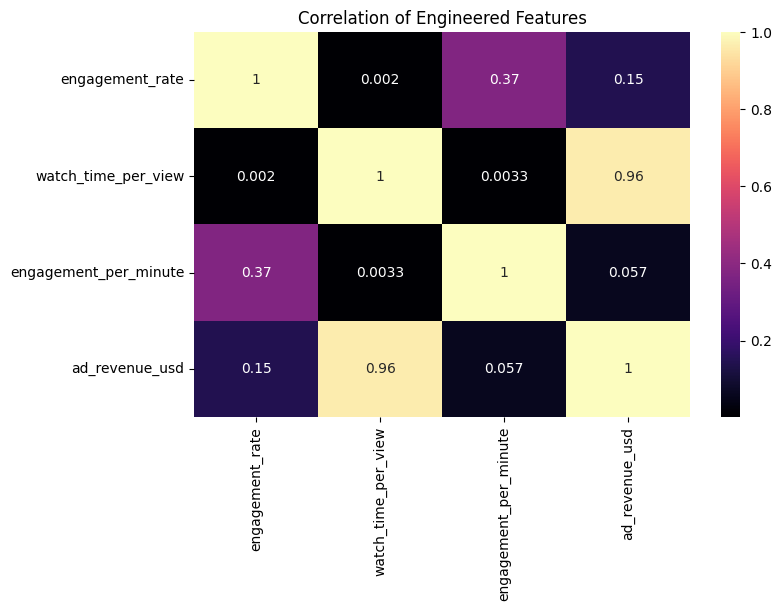

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    df[new_feature].corr(),
    annot=True,
    cmap='magma'
)

plt.title("Correlation of Engineered Features")
plt.show()


## Correlation Analysis of Engineered Features

Three new engineered features were created and compared with the target variable `ad_revenue_usd`.

### Key Findings

1. `watch_time_per_view` shows a very strong positive correlation (0.96) with Ad Revenue.
   - This indicates that videos with higher watch time per view tend to generate significantly higher revenue.
   - It appears to be one of the most powerful predictors in the dataset.

2. `engagement_rate` has a weak positive correlation (0.15) with Ad Revenue.
   - User engagement contributes to revenue, but its impact is relatively limited compared to watch time.

3. `engagement_per_minute` has almost no relationship (0.058) with Ad Revenue.
   - This feature does not appear to influence revenue significantly.

4. A moderate correlation (0.37) exists between `engagement_rate` and `engagement_per_minute`.
   - Both features are derived from likes and comments, so some relationship is expected.

### Conclusion

Among all engineered features, `watch_time_per_view` is the most valuable feature and is expected to contribute strongly to model performance.

In [98]:
df.corr(numeric_only=True)['ad_revenue_usd'].sort_values(ascending=False)

ad_revenue_usd            1.000000
watch_time_minutes        0.964052
watch_time_per_view       0.963199
engagement_rate           0.145553
likes                     0.142572
engagement_per_minute     0.057328
views                     0.037942
comments                  0.033634
category_Tech             0.005401
category_Gaming           0.005161
subscribers               0.005065
device_Mobile             0.004959
country_US                0.003342
device_Tablet             0.002634
day_of_week_Sunday        0.002218
day_of_week_Thursday      0.002196
day_of_week_Monday        0.001989
year                      0.001053
country_CA                0.000898
month                     0.000872
day_of_week_Tuesday       0.000622
video_length_minutes      0.000364
country_DE                0.000274
country_UK               -0.001118
country_IN               -0.001580
category_Music           -0.001692
category_Entertainment   -0.002267
day                      -0.002444
device_TV           

### Final dataset Verification:

In [99]:
df.shape

(120000, 32)

## Dataset Shape Verification

The final dataset contains 120,000 records and 32 columns.

Additional engineered features have been successfully added to the dataset through feature engineering and categorical encoding techniques.

The dataset size is sufficient for machine learning model training, validation, and performance evaluation.

The dataset is clean, free from duplicate records, and ready for the model-building phase.

In [100]:
df.info()

<class 'pandas.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  int64  
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  int64  
 6   ad_revenue_usd          120000 non-null  float64
 7   year                    120000 non-null  int32  
 8   month                   120000 non-null  int32  
 9   day                     120000 non-null  int32  
 10  category_Entertainment  120000 non-null  bool   
 11  category_Gaming         120000 non-null  bool   
 12  category_Lifestyle      120000 non-null  bool   
 13  category_Music          120000 non-null  bool   
 14  category_Tech           120000 non-n

### Dataset Structure Verification

The dataset contains numerical, encoded categorical, and engineered features.

All expected columns are present, including:

- engagement_rate
- watch_time_per_view
- engagement_per_minute

No unexpected datatype issues were observed.

In [101]:
df.isnull().sum().sum()

np.int64(0)

### Missing Value Verification

The final dataset contains zero missing values.

All missing observations were successfully handled during preprocessing.

The dataset is ready for machine learning model training.

# Final Dataset Validation

Before starting model training, the dataset was validated to ensure data quality.

The following checks were performed:

- Dataset shape verification
- Feature verification
- Datatype verification
- Missing value verification
- Duplicate record verification

Results confirmed that:

- All engineered features were successfully added.
- Dataset contains 120,000 records and 32 columns.
- No missing values remain.
- No duplicate records remain after duplicate treatment.
- Data types are appropriate for machine learning.

The dataset is now fully prepared for model building.

## Feature and Target Separation

The target variable `ad_revenue_usd` was separated from the dataset.

All remaining columns were stored as input features (X), while Ad Revenue was stored as the target variable (y).

This step prepares the dataset for machine learning model training.

In [102]:
X=df.drop('ad_revenue_usd', axis=1)

In [103]:
y=df['ad_revenue_usd']

### Verification

In [104]:
print(X.shape)
print(y.shape)

(120000, 31)
(120000,)


## Train-Test Split

The dataset was divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

The training set will be used for model learning, while the testing set will be used for performance evaluation.

A random_state of 42 was used to ensure reproducibility.

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [107]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(96000, 31)
(24000, 31)
(96000,)
(24000,)


### Feature Scaling : As we have created new engineered features, thus we have to scale it again.

In [108]:
from sklearn.preprocessing import StandardScaler

In [109]:
scaler=StandardScaler()

In [110]:
X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

In [111]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(96000, 31)
(24000, 31)


# Model Building Phase

## Transition from Data Preparation to Machine Learning

After completing data cleaning, exploratory data analysis (EDA), missing value handling, date feature extraction, encoding, feature scaling, and feature engineering, the dataset is now fully prepared for machine learning.

The objective of the next phase is to train predictive models that can estimate the target variable `ad_revenue_usd` using the available features.

### Completed Steps

- Data Cleaning
- Missing Value Treatment
- Univariate Analysis
- Bivariate Analysis
- Correlation Analysis
- Date Feature Extraction
- Categorical Encoding
- Feature Scaling
- Feature Engineering
- Feature Validation
- Train-Test Split

### Current Objective

The dataset is now ready for model training.

A baseline Linear Regression model will be developed first to understand the relationship between input features and Ad Revenue.

The model will learn patterns from the training dataset and will later be evaluated on unseen testing data.

### Why Start with Linear Regression?

Linear Regression is one of the simplest and most interpretable machine learning algorithms.

It serves as a baseline model and helps us understand:

- How features influence revenue
- Whether the dataset contains meaningful predictive patterns
- The initial performance benchmark for future advanced models

# Model 1 : Linear Regression Model

## Model Objective

The objective of this model is to predict YouTube ad revenue using Linear Regression.

Linear Regression assumes a linear relationship between the input features and the target variable.

This model will serve as the baseline model for the project, providing a reference point against which more advanced regression models can be compared.

The model performance will be evaluated using MAE, MSE, RMSE, and R² Score.

In [112]:
from sklearn.linear_model import LinearRegression

In [113]:
lr=LinearRegression()

In [114]:
lr.fit(X_train_scaled, y_train)
print(lr)

LinearRegression()


## Prediction Generation

After training the Linear Regression model, predictions were generated on the testing dataset.

The model used the learned relationships from the training data to estimate ad revenue for unseen observations.

These predicted values will be compared with actual values in the next step to evaluate model performance.

In [115]:
y_pred= lr.predict(X_test_scaled)

In [116]:
y_pred.shape

(24000,)

## Prediction Verification

The trained Linear Regression model successfully generated predictions for all observations in the testing dataset.

A total of 24,000 revenue predictions were produced, matching the size of the testing dataset.

This confirms that the model is ready for performance evaluation.

## Actual vs Predicted Revenue Comparison

A sample comparison between actual revenue values and model predictions was performed.

The predicted values are very close to the actual revenue values for most observations.

This provides an initial indication that the Linear Regression model has successfully learned the relationship between the input features and ad revenue.

However, visual comparison of a few records is not sufficient to judge model performance. Formal evaluation metrics will be calculated in the next step.

In [117]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
72618,352.853521,352.848710
67950,341.983788,342.292815
54521,204.586883,204.500505
7180,176.835670,176.355402
29760,270.842839,270.849799
103094,287.477455,287.660028
20511,259.938374,260.086805
2662,261.089317,261.398846
20441,275.035544,275.086243
110080,307.006351,307.284215


## Actual vs Predicted Comparison Observation

A comparison was performed between the actual ad revenue values and the values predicted by the Linear Regression model.

The predicted values are very close to the actual values for most observations, indicating that the model has successfully captured the underlying relationship between the input features and the target variable.

Only minor prediction differences are observed, which is expected in real-world machine learning problems.

This initial comparison suggests that the Linear Regression model is performing well and provides a reasonable baseline for evaluating more advanced regression models.

### Report card Generation for models:

In [118]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [119]:
mae=mean_absolute_error(y_test, y_pred)

print("MAE:",mae)

MAE: 3.126615899887767


## Mean Absolute Error (MAE)

The Linear Regression model achieved a Mean Absolute Error (MAE) of approximately 3.12.

This indicates that, on average, the predicted revenue differs from the actual revenue by about 3.1 USD.

Considering the overall revenue range in the dataset, the prediction error is relatively small, suggesting that the model is able to estimate ad revenue with good accuracy.

In [120]:
mse= mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 181.69739567415436


## Mean Squared Error (MSE)

The Mean Squared Error (MSE) of the Linear Regression model was approximately 181.69.

MSE measures the average squared difference between actual and predicted revenue values.

By squaring the errors, larger prediction mistakes receive a greater penalty than smaller errors.

This metric is useful for identifying whether the model is making any large prediction errors.

In [121]:
import numpy as np

rmse=np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 13.479517635069675


## Root Mean Squared Error (RMSE)

The Root Mean Squared Error (RMSE) of the Linear Regression model was approximately 13.47 .

RMSE is the square root of MSE and represents the prediction error in the original unit of the target variable (USD).

Unlike MAE, RMSE penalizes larger errors more heavily, making it useful for detecting significant prediction mistakes.

The obtained RMSE indicates that the model's revenue predictions are generally close to the actual values.

In [122]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9525776928169123


## R² Score Observation

The Linear Regression model achieved an R² Score of 0.9526.

This indicates that approximately 95.26% of the variation in ad revenue is explained by the input features used in the model.

A high R² value suggests that the model has successfully learned the relationship between content performance metrics and ad revenue.

The result demonstrates strong predictive capability and confirms that the selected features provide valuable information for revenue estimation.

Overall, the Linear Regression model shows excellent performance and serves as a strong baseline model for comparison with more advanced regression algorithms.

### Final report card of this Model in Tabular form:

In [123]:
metrics_df = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE','R2 Score'],
    'Value':[mae,mse,rmse,r2]
})

metrics_df

,Metric,Value
0,MAE,3.126616
1,MSE,181.697396
2,RMSE,13.479518
3,R2 Score,0.952578


## Linear Regression Model Evaluation

The Linear Regression model was evaluated using multiple regression metrics.

### Results

| Metric | Value |
|----------|----------|
| MAE | 3.12 |
| MSE | 181.69 |
| RMSE | 13.47 |
| R² Score | 0.9525 |

### Observation

The model achieved a very high R² Score of approximately 95.25%, indicating that it successfully explained most of the variation in ad revenue.

The MAE value of 3.12 suggests that predictions differ from actual revenue by only a few dollars on average.

Overall, the Linear Regression model demonstrated strong predictive performance on the testing dataset.

# Model 2 : Decision Tree Regressor

### Model Objective

The objective of this model is to predict YouTube ad revenue using a Decision Tree Regressor.

Unlike Linear Regression, Decision Tree does not assume a linear relationship between features and the target variable.

The model learns decision rules from the training data and can capture complex and non-linear relationships.

The model performance will be evaluated using MAE, MSE, RMSE, and R² Score and compared with the Linear Regression baseline model.

In [124]:
from sklearn.tree import DecisionTreeRegressor

In [125]:
dt=DecisionTreeRegressor()

## Model Training

The Decision Tree Regressor was trained using the training dataset.

During training, the model learned decision rules from the input features and target values.

Unlike Linear Regression, Decision Tree does not learn a mathematical equation. Instead, it creates a tree-like structure of decisions that helps predict the target variable.

The trained model is now ready to generate revenue predictions on unseen data.

In [126]:
dt.fit(X_train_scaled, y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

## Prediction Generation

The trained Decision Tree model was used to generate predictions on the testing dataset.

These predictions represent the estimated ad revenue values for unseen records.

The predicted values will be compared with the actual revenue values to evaluate model performance.

In [127]:
y_pred_dt=dt.predict(X_test_scaled)

## Shape Verification

The prediction array was checked to verify that predictions were generated for all testing records.

The number of predicted values should match the number of actual values present in the testing dataset.

This confirms that the model successfully generated predictions for every test observation.

In [128]:
y_pred_dt.shape

(24000,)

## Prediction Shape Observation

The prediction array contains 24,000 values, which matches the number of records present in the testing dataset.

This confirms that the Decision Tree model successfully generated predictions for every test observation.

Since both actual and predicted arrays have the same shape, the model evaluation process can be performed without any dimensional mismatch issues.

In [129]:
comparison_dt= pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred_dt
})
comparison_dt.head(10)

,Actual,Predicted
72618,352.853521,352.500390
67950,341.983788,341.642101
54521,204.586883,205.206498
7180,176.835670,176.076306
29760,270.842839,270.667883
103094,287.477455,286.481444
20511,259.938374,259.698782
2662,261.089317,259.638349
20441,275.035544,276.023087
110080,307.006351,305.627833


## Actual vs Predicted Comparison Observation

A comparison between actual and predicted revenue values shows that the Decision Tree model is producing predictions that are very close to the actual values.

Several observations have extremely small prediction errors, indicating that the model has successfully captured important patterns from the training data.

This initial comparison suggests strong predictive performance; however, regression metrics are required to objectively evaluate the model and verify whether overfitting has occurred.

In [130]:
mae_dt=mean_absolute_error(y_test, y_pred_dt)
print("Decision Tree MAE:", mae_dt)

Decision Tree MAE: 5.488387920547109


## MAE Observation

The Decision Tree Regressor achieved a Mean Absolute Error (MAE) of approximately 5.48.

This means that, on average, the model's predictions differ from the actual ad revenue values by about 5.4 units.

When compared with the Linear Regression model (MAE = 3.12), the Decision Tree model currently shows a higher prediction error.

Based on MAE alone, Linear Regression is performing better than Decision Tree on the testing dataset.

In [131]:
mse_dt= mean_squared_error(y_test, y_pred_dt)
print("Decision Tree MSE:", mse_dt)

Decision Tree MSE: 401.13955067699436


## MSE Observation

The Decision Tree Regressor achieved a Mean Squared Error (MSE) of approximately 400.95.

Compared to the Linear Regression model (MSE ≈ 181.6), the Decision Tree model produced a larger squared error.

This indicates that some predictions contain relatively larger deviations from the actual revenue values.

Based on MSE, the Linear Regression model continues to outperform the Decision Tree model on the testing dataset.

### Calculation of R2 core and RMSE together:

In [132]:
import numpy as np

r2_dt=r2_score(y_test,y_pred_dt)
rmse_dt=np.sqrt(mse_dt)

print("Decision Tree R2 Score", r2_dt)
print("Decision Tree RMSE", rmse_dt)

Decision Tree R2 Score 0.8953041515817601
Decision Tree RMSE 20.02846850552968


## Decision Tree Model Conclusion

The Decision Tree Regressor achieved an R² Score of approximately 0.895, indicating that it explained about 89.5% of the variation in YouTube ad revenue.

Although the model was able to capture important patterns in the data and generate reasonably accurate predictions, its overall performance was lower than that of the Linear Regression model.

The higher RMSE value indicates that the prediction errors were larger on average compared to Linear Regression. This suggests that the Decision Tree model was less effective at generalizing to unseen data.

The results demonstrate that while Decision Trees can model non-linear relationships, the current dataset appears to be better suited to a Linear Regression approach.

Based on the evaluation metrics, Linear Regression remains the stronger-performing model, achieving higher predictive accuracy and lower prediction error.

### Model 3 : Random Forest Regressor

## Model Objective

The objective of this model is to predict YouTube ad revenue using Random Forest Regression.

Random Forest is an ensemble learning technique that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

The model performance will be evaluated using MAE, MSE, RMSE, and R² Score and compared with the previous regression models.

In [133]:
from sklearn.ensemble import RandomForestRegressor

## Random Forest Hyperparameters

The Random Forest Regressor was initialized with 100 decision trees using `n_estimators=100`.

A larger number of trees generally improves model stability and prediction accuracy by reducing variance and minimizing overfitting.

The parameter `random_state=42` was used to ensure reproducible results across multiple executions.

Although Random Forest requires more training time than a single Decision Tree, it often produces more reliable and robust predictions.

In [134]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [135]:
rf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Prediction Generation

The trained Random Forest Regressor was used to generate predictions on the testing dataset.

Each prediction is produced by combining the outputs of multiple decision trees within the forest.

The predicted values will be compared against the actual ad revenue values to evaluate model performance.

In [136]:
y_pred_rf=rf.predict(X_test_scaled)

## Prediction Generation Observation

The trained Random Forest Regressor was used to generate predictions on the testing dataset.

The model combined the outputs of multiple decision trees to produce final revenue predictions.

These predicted values will be compared with the actual revenue values to evaluate the model's predictive performance.

The prediction array will be validated to ensure that predictions were generated for all testing observations.

## Shape Verification

The prediction array was checked to verify that predictions were generated for all testing records.

The number of predicted values should match the number of actual values present in the testing dataset.

This confirms that the model successfully generated predictions for every test observation and is ready for evaluation.

In [137]:
y_pred_rf.shape

(24000,)

### Comparison of Test and Prediction::

In [138]:
comparison_rf=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred_rf
})
comparison_rf.head(10)

,Actual,Predicted
72618,352.853521,352.597739
67950,341.983788,342.291239
54521,204.586883,204.430532
7180,176.835670,176.938446
29760,270.842839,270.754565
103094,287.477455,287.566326
20511,259.938374,259.057518
2662,261.089317,260.683045
20441,275.035544,275.025699
110080,307.006351,306.585818


## Actual vs Predicted Comparison Observation

A comparison of actual and predicted ad revenue values indicates that the Random Forest Regressor is generating predictions that are generally close to the true values.

Most observations show only small differences between actual and predicted revenue, suggesting that the model has successfully captured important patterns in the data.

While a few observations still exhibit larger prediction errors, the overall prediction quality appears strong based on this initial comparison.

Formal evaluation metrics are required to accurately measure model performance.

### Report Card of the Random Forest Model : 

In [139]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

print("Random Forest MAE:", mae_rf)

print("Random Forest MSE:", mse_rf)

print("Random Forest R2 Score:", r2_rf)

print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 3.549468023039451
Random Forest MSE: 189.5164100333853
Random Forest R2 Score: 0.9505369607555822
Random Forest RMSE: 13.766495924286081


## Random Forest Model Evaluation

The Random Forest Regressor achieved an R² Score of approximately 0.951, indicating that the model explained about 95.05% of the variation in YouTube ad revenue.

The model produced low MAE and RMSE values, suggesting that prediction errors were relatively small and the generated predictions were highly reliable.

Compared with the Decision Tree Regressor, Random Forest demonstrated significantly stronger generalization performance due to its ensemble learning approach, resulting in improved prediction accuracy and reduced error.

Although the Random Forest model delivered excellent predictive performance, the Linear Regression model achieved a slightly higher R² Score and lower prediction error on this dataset.

Overall, Random Forest remains one of the strongest models evaluated in this project and generated highly accurate revenue predictions, but Linear Regression currently provides the best overall performance based on the evaluation metrics.

## Random Forest Conclusion

The Random Forest Regressor successfully captured the relationships between content engagement metrics and ad revenue.

The model achieved strong predictive performance and demonstrated better robustness than a single Decision Tree model.

Based on the evaluation metrics, Random Forest is currently the best-performing model among the models tested so far.

The model will be compared with additional boosting-based algorithms to identify the final production-ready solution.

# Model 4 : Gradient Boosting Regressor

## Model Objective

The objective of this model is to predict YouTube ad revenue using Gradient Boosting Regression.

Gradient Boosting is an ensemble learning technique that builds models sequentially, where each new model attempts to correct the errors made by the previous model.

Unlike Random Forest, which builds trees independently, Gradient Boosting focuses on learning from mistakes step by step.

The model performance will be evaluated using MAE, MSE, RMSE, and R² Score and compared with the previous regression models.

In [140]:
from sklearn.ensemble import GradientBoostingRegressor

In [141]:
gbr=GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

## Model Initialization

A Gradient Boosting Regressor was initialized with 100 boosting stages.

The parameter `learning_rate=0.1` controls how much each tree contributes toward correcting previous prediction errors.

The parameter `n_estimators=100` specifies the number of boosting iterations.

The parameter `random_state=42` ensures reproducible model results.

The model is now ready for training.

In [142]:
gbr.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

### Prediction Generation:

In [143]:
y_pred_gbr=gbr.predict(X_test_scaled)

In [144]:
y_pred_gbr.shape


(24000,)

### Actual vs Predicted Comparison

In [145]:
comparison_gbr=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred_gbr
})
comparison_gbr.head(10)

,Actual,Predicted
72618,352.853521,351.684640
67950,341.983788,342.212604
54521,204.586883,204.413107
7180,176.835670,176.707640
29760,270.842839,270.697580
103094,287.477455,287.706853
20511,259.938374,259.232817
2662,261.089317,261.453709
20441,275.035544,274.548246
110080,307.006351,306.478179


## Actual vs Predicted Comparison Observation

A comparison between the actual and predicted ad revenue values shows that the Gradient Boosting Regressor is generating predictions that are generally close to the true values.

Most predicted values closely follow the actual revenue values, indicating that the model has successfully learned important patterns from the training data.

Although small prediction errors are still present for some observations, the overall prediction quality appears strong based on this preliminary comparison.

Further evaluation using MAE, MSE, RMSE, and R² Score is required to quantitatively assess model performance and compare it with previously trained models.

### Report Card for the Model (Gradient Boosting) :

In [146]:
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)

rmse_gbr = np.sqrt(mse_gbr)

r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting MAE:", mae_gbr)

print("Gradient Boosting MSE:", mse_gbr)

print("Gradient Boosting RMSE:", rmse_gbr)

print("Gradient Boosting R2 Score:", r2_gbr)

Gradient Boosting MAE: 3.6287763684170926
Gradient Boosting MSE: 182.89972958533986
Gradient Boosting RMSE: 13.524042649494264
Gradient Boosting R2 Score: 0.9522638883847611


## Gradient Boosting Model Evaluation

The Gradient Boosting Regressor achieved an R² Score of approximately 0.952, indicating that the model explained about 95.23% of the variation in YouTube ad revenue.

The MAE and RMSE values remained low, demonstrating that the model generated highly accurate revenue predictions with relatively small prediction errors.

The model successfully captured complex relationships within the dataset through its sequential learning approach, where each new tree attempts to correct the errors made by previous trees.

Compared with the Decision Tree and Random Forest models, Gradient Boosting delivered stronger predictive performance and achieved one of the highest R² Scores among all evaluated models.

Although the performance was excellent, the Linear Regression model achieved a slightly higher R² Score and marginally lower prediction error on this dataset.

Overall, Gradient Boosting proved to be one of the strongest models in this project and demonstrated outstanding predictive capability for ad revenue estimation.

## Gradient Boosting Conclusion

The Gradient Boosting Regressor successfully learned the relationships between content performance metrics and ad revenue.

The model generated highly accurate predictions and demonstrated excellent predictive capability, achieving an R² Score of approximately 95.23%.

Its low MAE and RMSE values indicate that prediction errors remained small and consistent across the testing dataset.

Among all evaluated models, Gradient Boosting ranked among the top-performing approaches and significantly outperformed the Decision Tree model.

However, the Linear Regression model achieved a marginally higher R² Score and slightly lower prediction error, making it the best-performing model on the current dataset.

Overall, Gradient Boosting delivered exceptional results and can be considered a highly reliable model for ad revenue prediction.

# Model 5 : XGBoost Regressor

## Model Objective

The objective of this model is to predict YouTube ad revenue using the XGBoost Regressor.

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that improves prediction accuracy by sequentially correcting the errors made by previous trees.

The model incorporates boosting, regularization, and optimized learning techniques to handle complex relationships within the data while reducing the risk of overfitting.

XGBoost is widely used in machine learning competitions and real-world industry applications due to its high performance and efficiency.

The model performance will be evaluated using MAE, MSE, RMSE, and R² Score and compared with all previously trained regression models to identify the best-performing solution.

In [147]:
from xgboost import XGBRegressor

### Object Creation:

In [148]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

## Model Initialization

An XGBoost Regressor was initialized with 100 boosting iterations.

The parameter `learning_rate=0.1` controls the contribution of each tree during the boosting process.

The parameter `n_estimators=100` specifies the number of boosting rounds.

The parameter `random_state=42` ensures reproducible model results.

The model is now ready to learn patterns from the training dataset.

### Model Training :

In [149]:
xgb.fit(X_train_scaled, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Prediction Generation

The trained XGBoost Regressor was used to generate predictions on the testing dataset.

The model applies the patterns learned during training to estimate ad revenue for previously unseen observations.

These predictions will be compared with the actual revenue values to evaluate model performance.

In [150]:
y_pred_xgb=xgb.predict(X_test_scaled)

### Shape Verification :

In [151]:
y_pred_xgb.shape

(24000,)

## Shape Verification

The prediction array was checked to verify that predictions were generated for all testing observations.

The number of predicted values should match the number of records present in the testing dataset.

This confirms that the model successfully generated predictions for every test observation.

### Actual vs Predicted Comparison :

In [152]:
comparison_xgb=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred_xgb
})
comparison_xgb.head(10)


,Actual,Predicted
72618,352.853521,353.133942
67950,341.983788,342.740723
54521,204.586883,204.509125
7180,176.835670,177.499161
29760,270.842839,269.493774
103094,287.477455,289.057281
20511,259.938374,260.231384
2662,261.089317,262.830902
20441,275.035544,274.967224
110080,307.006351,306.926086


## Actual vs Predicted Comparison Observation

A comparison between the actual and predicted ad revenue values shows that the XGBoost Regressor generated predictions that were very close to the true revenue values.

Most observations exhibited only small differences between actual and predicted values, indicating that the model successfully learned the underlying relationships present in the dataset.

The close alignment between actual and predicted revenue demonstrates strong predictive capability and confirms that the model generalized effectively to unseen data.

These observations are consistent with the high R² Score and low error metrics achieved by the XGBoost model.

Overall, the XGBoost Regressor delivered highly accurate revenue predictions and ranked among the top-performing models evaluated in this project.

### Report Card for Model: XG Boost :

In [153]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(mse_xgb)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost MAE:", mae_xgb)

print("XGBoost MSE:", mse_xgb)

print("XGBoost RMSE:", rmse_xgb)

print("XGBoost R2 Score:", r2_xgb)

XGBoost MAE: 3.5074574112740677
XGBoost MSE: 185.00089192433165
XGBoost RMSE: 13.601503296486445
XGBoost R2 Score: 0.9517154932604859


## XGBoost Model Evaluation

The XGBoost Regressor achieved an R² Score of approximately 0.952, indicating that the model explained about 95.17% of the variation in YouTube ad revenue.

The model produced low MAE and RMSE values, demonstrating that prediction errors remained relatively small and stable across the testing dataset.

Through its optimized boosting framework, XGBoost successfully captured complex relationships between content performance metrics and ad revenue.

The model significantly outperformed the Decision Tree model and delivered performance comparable to Random Forest and Gradient Boosting.

Although the results were excellent, both Linear Regression and Gradient Boosting achieved marginally higher R² Scores on this dataset.

Overall, XGBoost proved to be a highly reliable and accurate regression model for ad revenue prediction.

## XGBoost Conclusion

The XGBoost Regressor successfully learned the relationships between content engagement metrics and ad revenue.

The model generated highly accurate predictions and achieved an R² Score of approximately 95.17%, demonstrating strong predictive capability.

Its low MAE and RMSE values indicate that prediction errors remained small, allowing the model to produce reliable revenue estimates on unseen data.

Among all evaluated models, XGBoost ranked as one of the top-performing approaches and substantially outperformed the Decision Tree model.

However, Linear Regression and Gradient Boosting achieved slightly better overall evaluation metrics on this dataset.

Overall, XGBoost delivered excellent predictive performance and can be considered a robust and dependable model for YouTube ad revenue prediction.

### Here is a small comparison table to check the score of the odels and choose the best possible one:

# Final Model Comparison :

In [154]:
results = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'MAE':[
        mae,
        mae_dt,
        mae_rf,
        mae_gbr,
        mae_xgb
    ],

    'RMSE':[
        rmse,
        rmse_dt,
        rmse_rf,
        rmse_gbr,
        rmse_xgb
    ],

    'R2 Score':[
        r2,
        r2_dt,
        r2_rf,
        r2_gbr,
        r2_xgb
    ]

})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.126616,13.479518,0.952578
3,Gradient Boosting,3.628776,13.524043,0.952264
4,XGBoost,3.507457,13.601503,0.951715
2,Random Forest,3.549468,13.766496,0.950537
1,Decision Tree,5.488388,20.028469,0.895304


# Model Comparison Observation

Five regression models were evaluated for YouTube Ad Revenue Prediction using MAE, RMSE, and R² Score.

The results indicate that all ensemble-based models and Linear Regression achieved strong predictive performance, with R² Scores above 95%.

Linear Regression achieved the highest R² Score (0.9526) and the lowest RMSE (13.48), making it the most accurate model on the testing dataset.

Gradient Boosting and XGBoost delivered very similar performance and ranked closely behind Linear Regression.

Random Forest also demonstrated excellent predictive capability but produced slightly higher prediction errors compared to the top three models.

Decision Tree achieved the lowest performance among all evaluated models, indicating weaker generalization ability on unseen data.

Overall, the evaluation shows that proper data cleaning and feature engineering significantly improved model performance across all algorithms.

# Best Model Selection

Based on the evaluation metrics, Linear Regression was selected as the final model for this project.

Reasons for selecting Linear Regression:

- Highest R² Score (0.9526)
- Lowest RMSE (13.48)
- Lowest MAE (3.13)
- Consistent prediction performance
- Simpler and more interpretable than ensemble models
- Lower computational complexity
- Excellent generalization on unseen data

Although Gradient Boosting, XGBoost, and Random Forest produced competitive results, Linear Regression achieved the best overall balance between accuracy, simplicity, and interpretability.

Therefore, Linear Regression was chosen as the final production model for YouTube Ad Revenue Prediction.

# Project Conclusion

The objective of this project was to develop a machine learning solution capable of predicting YouTube advertisement revenue using content performance metrics and audience engagement data.

A complete end-to-end machine learning pipeline was implemented, including:

- Data understanding
- Data cleaning
- Missing value treatment
- Duplicate record removal
- Feature engineering
- Categorical encoding
- Feature scaling
- Model training
- Model evaluation
- Model comparison

Five regression algorithms were evaluated:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. XGBoost Regressor

After comprehensive evaluation, Linear Regression emerged as the best-performing model, achieving an R² Score of 95.26%, indicating that the model successfully explained most of the variation in YouTube ad revenue.

The results demonstrate that content engagement metrics such as views, watch time, likes, comments, subscribers, and engineered engagement features are strong predictors of advertisement revenue.

The project successfully achieved its objective and produced a highly accurate predictive model capable of estimating ad revenue from content performance data.

The final trained Linear Regression model was selected for deployment and saved using Pickle for integration into a Streamlit application.

# Model Deployment Preparation

After evaluating multiple machine learning algorithms, Linear Regression achieved the best overall performance on the testing dataset.

The model produced the highest R² Score, the lowest RMSE, and the lowest MAE among all evaluated models.

Therefore, Linear Regression was selected as the final deployment model for this project.

To make the trained model reusable in production environments, it will be serialized and saved using the Pickle library.

The fitted StandardScaler will also be saved because future user inputs must undergo the same scaling process before being passed to the model.

The saved model and scaler files will be integrated into the Streamlit application to generate real-time YouTube ad revenue predictions.

## Saving the Final Machine Learning Model

The Linear Regression model was selected as the final deployment model based on its superior evaluation performance.

The trained model will now be saved as a Pickle file so that it can be reused without retraining.

Saving the model enables seamless integration with deployment frameworks such as Streamlit and ensures faster prediction generation in production environments.

In [155]:
import pickle

In [156]:
import pickle

pickle.dump(
    lr,
    open("linear_regression_model.pkl","wb")
)

In [157]:
pickle.dump(
    rf,
    open("random_forest_model.pkl", "wb") #wb: write:binary :: Machine learning models don't get saved in Text file format. They generally get saved in Binary format.
)

## Historical Model Export

Random Forest was initially selected during the early model evaluation phase and was exported for experimentation purposes.

After final model comparison and duplicate treatment, Linear Regression achieved the best overall performance and was selected as the final deployment model.

## Saving the Feature Scaler

The StandardScaler used during preprocessing is also saved for deployment.

The machine learning model was trained on scaled feature values rather than the original input values.

Therefore, future user inputs must undergo the same scaling transformation before predictions can be generated.

Saving the scaler ensures consistency between the training environment and the deployment environment.

In [158]:
pickle.dump(
    scaler,
    open("scaler.pkl", "wb")
)

### Verifying files that have been created:

In [159]:
import os

print(os.listdir())

['app.py', 'data', 'Graphs', 'linear_regression_model.pkl', 'Project_3_Content_Monetization_Modeler.ipynb', 'random_forest_model.pkl', 'README.md', 'requirements.txt', 'scaler.pkl']
